In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [3]:
# Load the Toyota cars dataset
df = pd.read_excel('toyota_cars.xlsx', sheet_name='toyota_cars')
df.head(10)

,model,price,dimensions,wheelbase,seats,engine_type,engine_displacement,max_ouput,max_torque,fuel,power_transmission,brake,tires,wheels_size
0,Camry,2355000,"4,885 x 1,840 x 1,445",-,5,"16-Valve DOHC, 4-Cylinder, In-line, VVT-iE (In...",2487,178 / 5700,"221 / 3,600 ~ 5,200",50L,CVT,Ventilated Disc / Solid Disc,235 / 45R18 Alloy,"18"" Alloy"
1,Corolla Altis,1302000,"4,630 x 1,780 x 1,435",2700,5,"Dual VVT-I, 4-Cylinder In-Line DOHC, 16 Valve",1598,"121 hp / 6,000 rpm","153 Nm / 5,200 rpm",50,CVT,Ventilated Discs / Solid Discs,225 / 45R17 Aluminum Alloy with machined finish,-
2,GR Yaris,2740000,"3,995 x 1,805 x 1,455",2560,4,"3-Cylinder, In-line, DOHC 4-Valve Roller-rocker",1618,261/6500,360/3000-4600,50,6-Speed MT,Ventilated Disc with 4-Cylinder Fixed Caliper ...,225,40R18 BBS Forged Alloy
3,Prius,2436000,"4,480 x 1,745 x 1,480",2700,5,"Hybrid Synergy Drive, Variable Valve Timing - ...",1786,73 / 5200,142 Nm / 4000,45,Electronically Controlled Continuously Variabl...,Ventilated Discs / Solid Discs,195,65 R15 Alloy
4,Vios,985000,"4,425 x 1,730 x 1,475",2550,5,"Dual VVT-I, 4-Cylinder In-LineDOHC 16V EFI",1496,"107PS/6,000rpm","140Nm/4,200rpm",42,CVT,Ventilated Discs / Solid Disc,195/50 R16 Alloy,-
5,Vios GR-S,1035000,"4,467 x 1,730 x 1,475",2550,5,"Dual VVT-I, 4-Cylinder In-LineDOHC 16V EFI",1496,"107PS/6,000rpm","140Nm / 4,200rpm",42,CVT,Ventilated Discs/Solid Disc,195/50 R16 Alloy,16 inches Alloy
6,Wigo,705000,"3,700 x 1,600 x 1,520",-,5,3 Cylinder In-line,998,66 / 6000,89 / 4400,-,4-Speed A/T,Ventilated Disc / Drum,175 / 65R14,"14"" x 5J Alloy (Machine Cut Design)"
7,Yaris,1114000,"4,140 x 1,730 x 1,500",-,5,"4-cylinder, In-line 16-valve DOHC, Chain Drive...",1496,107PS/6000Rpm,140Nm / 4200Rpm,-,CVT,Ventilated Disc / Solid Disc,185,60R15 Alloy
8,Corolla Cross,1774000,"4,455 x 1,825 x 1,620",-,-,"16-Valve DOHC, 4-Cylinder, In-line,",1798,"98 / 5,200",3600,-,-,Ventilated Discs/Solid Discs,225/50 R18,"18"" Alloy"
9,FJ Cruiser,2218000,"4,670 x 1,905 x 1,830",2690,5,"6-cylinders, V-Type, 24-valve DOHC with dual V...",3956,"268 / 5,600","380 / 4,400",-,5-Speed Automatic,"16"" Disk / 15"" Disk",265 / 70 R17,17 x 7.5J


**TASK1**: Data Quality Assessment

In [4]:
df.dtypes


,0
model,object
price,int64
dimensions,object
wheelbase,object
seats,object
engine_type,object
engine_displacement,int64
max_ouput,object
max_torque,object
fuel,object


In [6]:
df_clean = df.copy()

df_clean['price'] = df_clean['price'].astype(str).str.replace(',', '').str.extract(r'(\d+)').astype(float)

df_clean['engine_displacement'] = pd.to_numeric(df_clean['engine_displacement'], errors='coerce')

df_clean['seats'] = pd.to_numeric(df_clean['seats'], errors='coerce')

df_clean.dtypes

,0
model,object
price,float64
dimensions,object
wheelbase,object
seats,float64
engine_type,object
engine_displacement,int64
max_ouput,object
max_torque,object
fuel,object


**Task2** : Handling Missing Values

In [7]:
df_clean.isna().sum()

,0
model,0
price,0
dimensions,0
wheelbase,0
seats,1
engine_type,0
engine_displacement,0
max_ouput,0
max_torque,0
fuel,0


In [8]:
print("Missing values in 'seats' before:", df_clean['seats'].isnull().sum())

median_seats = df_clean['seats'].median()
print("Median value for seats:", median_seats)

df_clean['seats'].fillna(median_seats, inplace=True)

print("Missing values in 'seats' after:", df_clean['seats'].isnull().sum())

Missing values in 'seats' before: 1
Median value for seats: 5.0
Missing values in 'seats' after: 0


/tmp/ipykernel_838/2691914563.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['seats'].fillna(median_seats, inplace=True)


**Task 3**: Handling Outliers

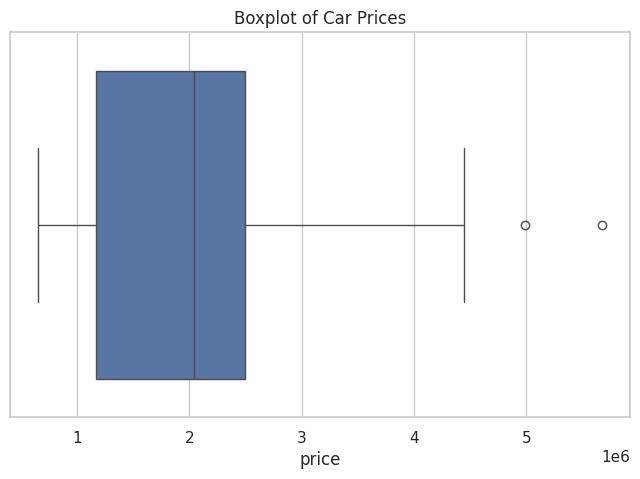

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['price'])
plt.title("Boxplot of Car Prices")
plt.show()

Detect Outliers using IQR

In [10]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['price'] < lower) | (df_clean['price'] > upper)]
print("Number of outliers:", len(outliers))
outliers[['model', 'price']]

Number of outliers: 2


,model,price
12,Land Cruiser,5672000.0
32,GR Supra,4990000.0


Remove Outliers

In [11]:
df_no_outliers = df_clean[(df_clean['price'] >= lower) & (df_clean['price'] <= upper)]

print("Original shape:", df_clean.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (33, 14)
After removing outliers: (31, 14)


**Task 4**: Data Transformation – Normalization

In [12]:
numerical_cols = ['price', 'engine_displacement', 'seats']

print("Original values:")
df_no_outliers[numerical_cols].head()

Original values:


,price,engine_displacement,seats
0,2355000.0,2487,5.0
1,1302000.0,1598,5.0
2,2740000.0,1618,4.0
3,2436000.0,1786,5.0
4,985000.0,1496,5.0


In [13]:
df_num = df_no_outliers[numerical_cols].dropna()

scaler = MinMaxScaler()
df_minmax = df_num.copy()
df_minmax[numerical_cols] = scaler.fit_transform(df_num)

print("After Min-Max Normalization (values between 0 and 1):")
df_minmax.head()

After Min-Max Normalization (values between 0 and 1):


,price,engine_displacement,seats
0,0.448904,0.494520,0.111111
1,0.170848,0.199269,0.111111
2,0.550568,0.205912,0.074074
3,0.470293,0.261707,0.111111
4,0.087140,0.165394,0.111111


Z-Score Normalization

In [14]:
scaler = StandardScaler()
df_zscore = df_num.copy()
df_zscore[numerical_cols] = scaler.fit_transform(df_num)

print("After Z-score Standardization (mean=0, std=1):")
df_zscore.head()

After Z-score Standardization (mean=0, std=1):


,price,engine_displacement,seats
0,0.368749,0.252207,-0.420889
1,-0.716747,-0.883135,-0.420889
2,0.765630,-0.857593,-0.624757
3,0.452248,-0.643040,-0.420889
4,-1.043530,-1.013400,-0.420889


**Task 5**: Data Reduction (PCA)

In [15]:
X = df_zscore[numerical_cols]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1 and PC2:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.69573256 0.19965272]
Total variance explained by PC1 and PC2: 0.8953852796149759
